# Preprocessing 
## GEO ScRNA-seq Dataset ID: GSE212966.
Dataset retreived from: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE212966 \
Datset name: Single-cell RNA-seq reveals immune landscape of pancreatic cancer

In [1]:
import os

In [2]:
os.getcwd()

'/Users/iriskwon/Documents/CG_Final_Proj_Dir/CompGenFinalProject'

In [3]:
path = '/Users/iriskwon/Library/CloudStorage/OneDrive-JohnsHopkins/CG_Final_Proj'
os.chdir(path)
files = os.listdir()
print(files)

['.DS_Store', 'Code', 'Raw_Data']


Each file name is structured as: 
`[GSM_ID]_[SAMPLE]_[filetype]`

In [4]:
# extract sample names in our dataset
sample_info = set()
samples = set() # unique samples
gsm_ids = set() # unique GSM IDs
for f in files: 
    parts = f.split('_') 
    if len(parts) > 2: 
        gsm_id = parts[0] # get GSM unique sample ID 
        sample = parts[1] # get sample name 
        gsm_ids.add(gsm_id)
        samples.add(sample)
        sample_info.add((gsm_id,sample))

print(sorted(sample_info))

[('GSM6567157', 'PDAC1'), ('GSM6567159', 'PDAC2'), ('GSM6567160', 'PDAC3'), ('GSM6567161', 'PDAC4'), ('GSM6567163', 'PDAC5'), ('GSM6567164', 'PDAC6'), ('GSM6567165', 'ADJ1'), ('GSM6567166', 'ADJ2'), ('GSM6567167', 'ADJ3'), ('GSM6567169', 'ADJ4'), ('GSM6567170', 'ADJ5'), ('GSM6567171', 'ADJ6')]


In [5]:
print(samples, len(samples)) # 12 unique samples in our data

{'ADJ1', 'PDAC6', 'PDAC3', 'ADJ6', 'PDAC1', 'PDAC2', 'ADJ5', 'PDAC5', 'ADJ4', 'PDAC4', 'ADJ3', 'ADJ2'} 12


In [6]:
print(sorted(gsm_ids), len(gsm_ids)) # 12 unique gsm_ids in our dataset 

['GSM6567157', 'GSM6567159', 'GSM6567160', 'GSM6567161', 'GSM6567163', 'GSM6567164', 'GSM6567165', 'GSM6567166', 'GSM6567167', 'GSM6567169', 'GSM6567170', 'GSM6567171'] 12


Dataset Overview: 
-  Multiple samples: 
    - `PDAC1-PDAC6`: tumor samples (from pancreatic ductal adenocarcinoma)
    -  `ADJ1-ADJ6`: adjacent normal tissues 

### Preprocessing each sample scRNA-seq

In [7]:
from collections import defaultdict
import scanpy as sc

files = os.listdir()

gsm_to_files = defaultdict(list)

for f in files:
    parts = f.split('_')
    if len(parts) >= 2:
        gsm = parts[0]
        gsm_to_files[gsm].append(f)

In [8]:
print(gsm_to_files)

defaultdict(<class 'list'>, {'GSM6567157': ['GSM6567157_PDAC1_matrix.mtx.gz', 'GSM6567157_PDAC1_barcodes.tsv.gz', 'GSM6567157_PDAC1_genes.tsv.gz'], 'GSM6567160': ['GSM6567160_PDAC3_matrix.mtx.gz', 'GSM6567160_PDAC3_barcodes.tsv.gz', 'GSM6567160_PDAC3_genes.tsv.gz'], 'GSM6567161': ['GSM6567161_PDAC4_matrix.mtx.gz', 'GSM6567161_PDAC4_genes.tsv.gz', 'GSM6567161_PDAC4_barcodes.tsv.gz'], 'GSM6567165': ['GSM6567165_ADJ1_matrix.mtx.gz', 'GSM6567165_ADJ1_genes.tsv.gz', 'GSM6567165_ADJ1_barcodes.tsv.gz'], 'GSM6567166': ['GSM6567166_ADJ2_matrix.mtx.gz', 'GSM6567166_ADJ2_barcodes.tsv.gz', 'GSM6567166_ADJ2_genes.tsv.gz'], 'GSM6567167': ['GSM6567167_ADJ3_matrix.mtx.gz', 'GSM6567167_ADJ3_barcodes.tsv.gz', 'GSM6567167_ADJ3_genes.tsv.gz'], 'GSM6567169': ['GSM6567169_ADJ4_matrix.mtx.gz', 'GSM6567169_ADJ4_genes.tsv.gz', 'GSM6567169_ADJ4_barcodes.tsv.gz'], 'GSM6567159': ['GSM6567159_PDAC2_genes.tsv.gz', 'GSM6567159_PDAC2_matrix.mtx.gz', 'GSM6567159_PDAC2_barcodes.tsv.gz'], 'GSM6567171': ['GSM6567171_ADJ6

In [9]:
# Load each GSM anndata 
adatas = []

for gsm, flist in gsm_to_files.items():
    
    matrix = [f for f in flist if 'matrix' in f][0]
    genes = [f for f in flist if 'genes' in f][0]
    barcodes = [f for f in flist if 'barcodes' in f][0]
    
    adata = sc.read_mtx(matrix).T  # transpose: cells x genes
    
    # Load genes + barcodes
    import pandas as pd
    genes_df = pd.read_csv(genes, header=None, sep='\t')
    barcodes_df = pd.read_csv(barcodes, header=None)
    
    adata.var_names = genes_df[0].values
    adata.obs_names = barcodes_df[0].values
    
    # --- Add metadata ---
    sample = matrix.split('_')[1]
    
    adata.obs['gsm'] = gsm
    adata.obs['sample'] = sample
    adata.obs['condition'] = 'PDAC' if 'PDAC' in sample else 'ADJ'
    
    adatas.append(adata)

#### Preprocessing one sample for sanity check 

In [10]:
adatas[0]

AnnData object with n_obs × n_vars = 8056 × 36601
    obs: 'gsm', 'sample', 'condition'

In [11]:
first_item = next(iter(gsm_to_files.items()))
gsm, files = first_item

print(gsm)
print(files)

GSM6567157
['GSM6567157_PDAC1_matrix.mtx.gz', 'GSM6567157_PDAC1_barcodes.tsv.gz', 'GSM6567157_PDAC1_genes.tsv.gz']


The first sample is a PDAC1 (tumor sample)!

In [12]:
import scanpy as sc 
import pandas as pd 

matrix = 'GSM6567157_PDAC1_matrix.mtx.gz'
genes = 'GSM6567157_PDAC1_genes.tsv.gz'
barcodes = 'GSM6567157_PDAC1_barcodes.tsv.gz'

adata = sc.read_mtx(matrix).T  # cells × genes

In [13]:
adata # sample as adatas[0]

AnnData object with n_obs × n_vars = 8056 × 36601

In [14]:
genes_df = pd.read_csv(genes, header=None, sep='\t')
barcodes_df = pd.read_csv(barcodes, header=None)

adata.var_names = genes_df[1].values  # gene symbols
adata.obs_names = barcodes_df[0].values

adata.var_names_make_unique()

In [15]:
genes_df.iloc[:,2].unique()

array(['Gene Expression'], dtype=object)

In [16]:
adata.obs['gsm'] = 'GSM6567157'
adata.obs['sample'] = 'PDAC1'
adata.obs['condition'] = 'PDAC'

In [17]:
print(adata.shape)

(8056, 36601)


In [18]:
print(adata.var_names[:20])

Index(['MIR1302-2HG', 'FAM138A', 'OR4F5', 'AL627309.1', 'AL627309.3',
       'AL627309.2', 'AL627309.5', 'AL627309.4', 'AP006222.2', 'AL732372.1',
       'OR4F29', 'AC114498.1', 'OR4F16', 'AL669831.2', 'LINC01409', 'FAM87B',
       'LINC01128', 'LINC00115', 'FAM41C', 'AL645608.6'],
      dtype='object')


### QC for the first sample 

In [19]:
# Check mitochondrial genes 
adata.var_names = adata.var_names.str.upper()
adata.var['mt'] = adata.var_names.str.startswith('MT-')

print(sum(adata.var['mt'])) # 13 mitochondrial genes 

13


In [20]:
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
print(sum(adata.var["ribo"])) # 103 ribosomal genes 

103


In [21]:
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
print(sum(adata.var['hb'])) # 12 hemoglobin genes 

12


In [22]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


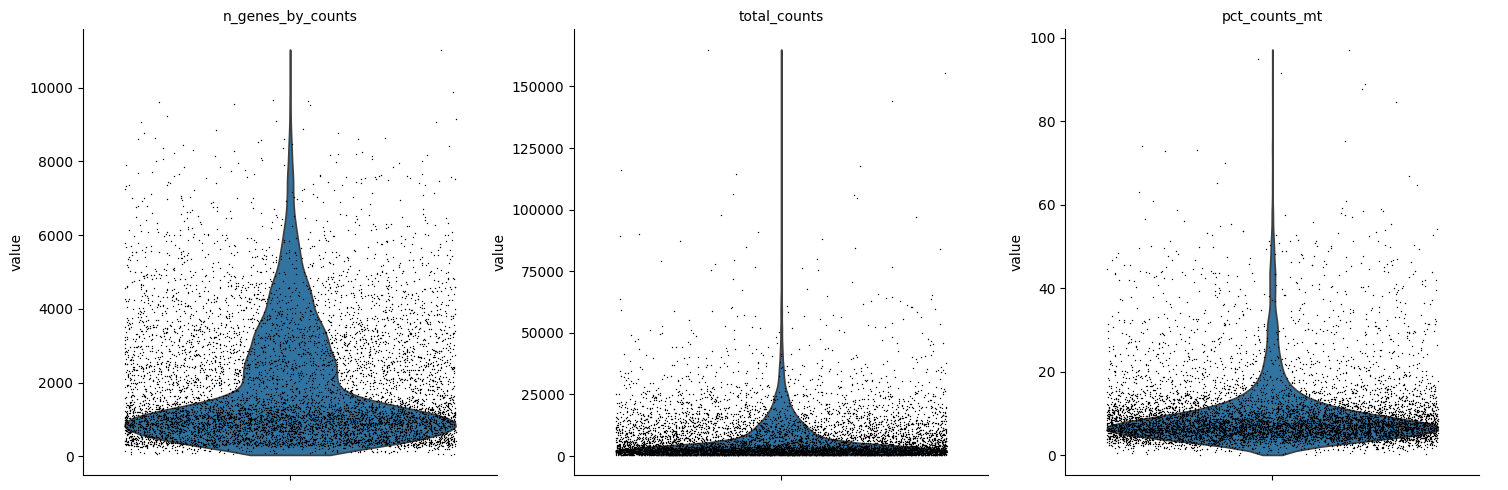

In [23]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

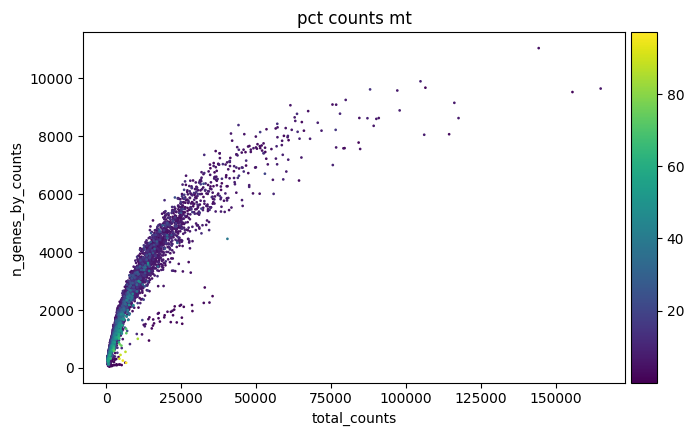

In [24]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")


In [25]:
adata.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt']].mean()

n_genes_by_counts    1888.624628
total_counts         7099.786621
pct_counts_mt          10.056926
dtype: float64

In [26]:
adata.obs['total_counts'].describe()

count      8056.000000
mean       7099.786621
std       10364.338867
min         500.000000
25%        1742.750000
50%        3176.500000
75%        8679.750000
max      164953.000000
Name: total_counts, dtype: float64

In [27]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

In [28]:
sc.pp.scrublet(adata, batch_key="sample")

In [29]:
adata = adata[adata.obs.n_genes_by_counts > 300, :]
adata = adata[adata.obs.n_genes_by_counts < 5000, :]

adata = adata[adata.obs.total_counts > 1000, :]
adata = adata[adata.obs.total_counts < 25000, :]

adata = adata[adata.obs.pct_counts_mt < 15, :]

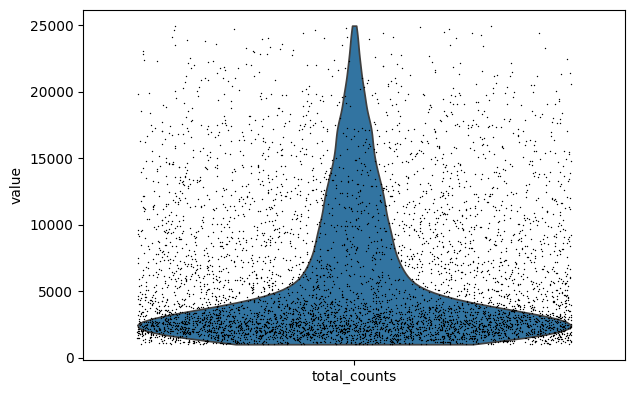

In [30]:
sc.pl.violin(adata, ['total_counts'], jitter=0.4)

In [31]:
adata.layers['counts'] = adata.X.copy() # save counts (before norm)

/var/folders/jc/r13c712s6dj2g5bnkv832wk40000gn/T/ipykernel_22905/374595293.py:1: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata.layers['counts'] = adata.X.copy() # save counts (before norm)


In [32]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [35]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

In [38]:
# keep only the HVGs 
adata = adata[:, adata.var.highly_variable]

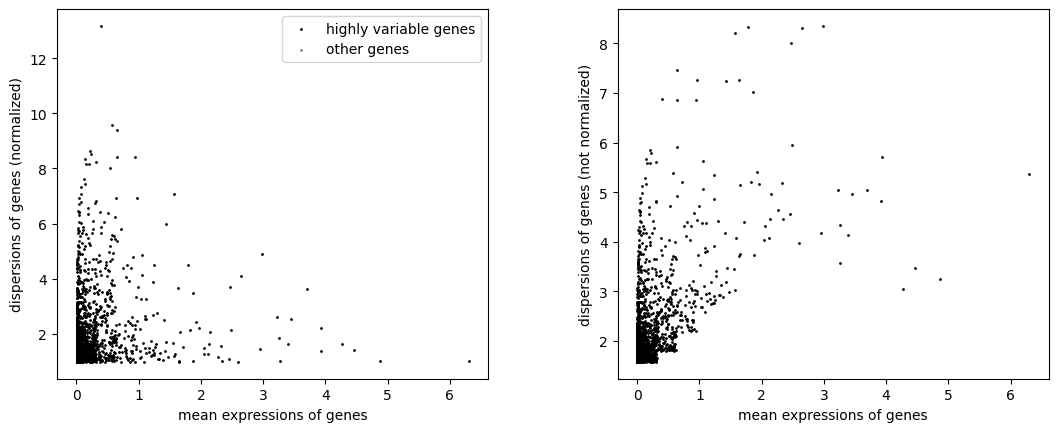

In [39]:
sc.pl.highly_variable_genes(adata)

In [40]:
sc.pp.scale(adata, max_value=10)

/Users/iriskwon/.local/share/virtualenvs/STalign-hu3yymDJ/lib/python3.12/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/Users/iriskwon/miniforge3/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [41]:
sc.tl.pca(adata, svd_solver='arpack')

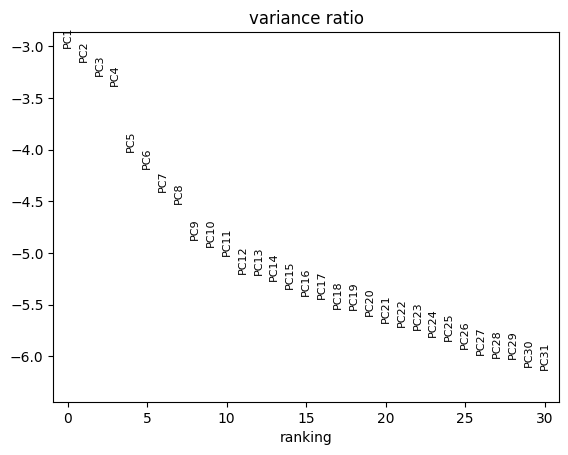

In [42]:
sc.pl.pca_variance_ratio(adata, log=True)

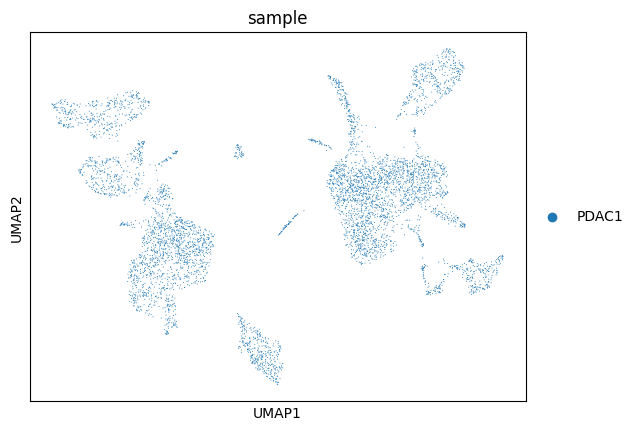

In [58]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=30)
sc.tl.umap(adata)
sc.pl.umap(
    adata,
    color="sample",
    # Setting a smaller point size to get prevent overlap
    size=2,
)

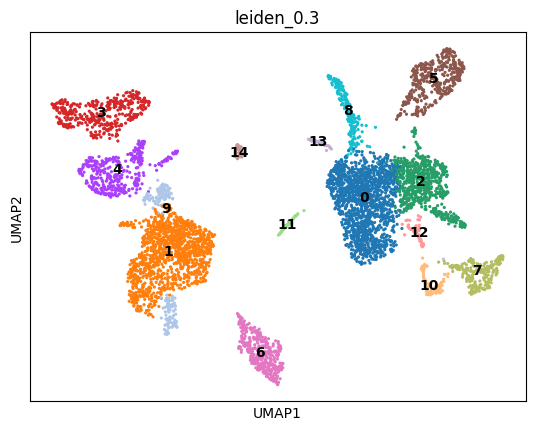

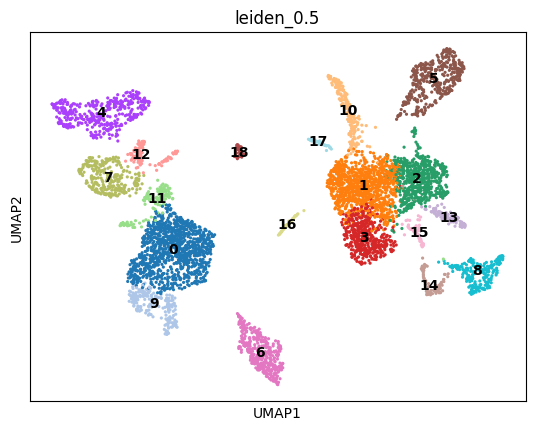

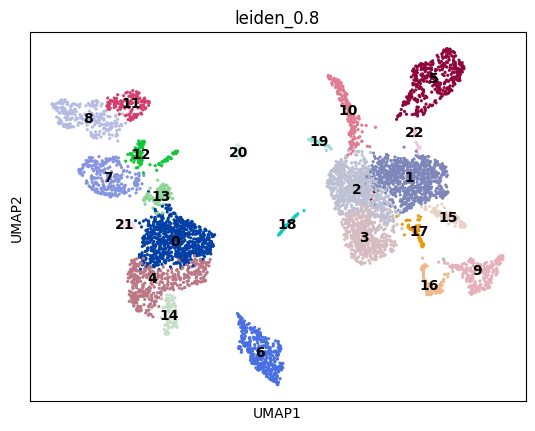

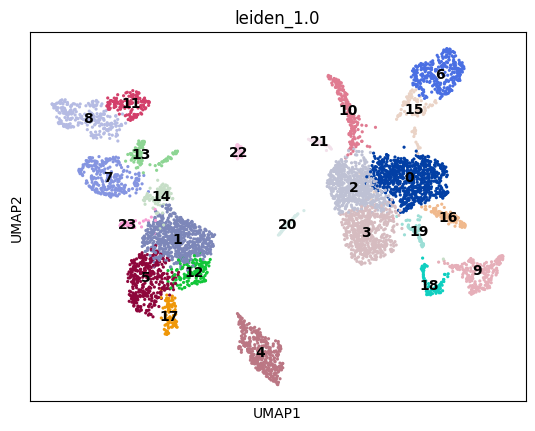

In [55]:
for r in [0.3, 0.5, 0.8, 1.0]:
    sc.tl.leiden(adata, resolution=r, key_added=f'leiden_{r}')
    sc.pl.umap(adata, color=[f'leiden_{r}'], legend_loc="on data")

In [59]:
sc.tl.leiden(adata, resolution=0.5)

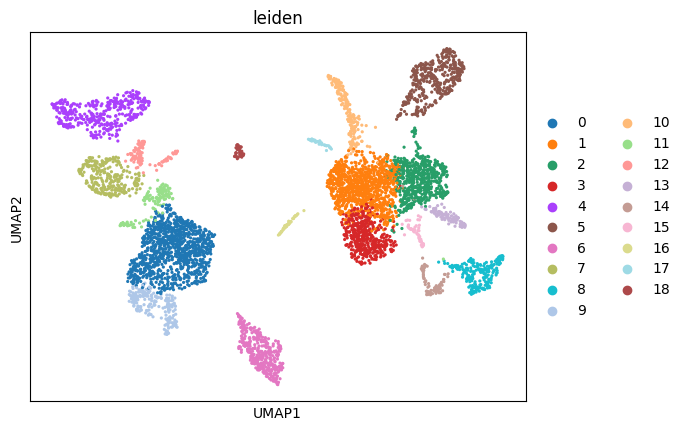

In [60]:
sc.pl.umap(adata, color=['leiden'])

In [61]:
# Find marker genes 
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')

/Users/iriskwon/.local/share/virtualenvs/STalign-hu3yymDJ/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/iriskwon/.local/share/virtualenvs/STalign-hu3yymDJ/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/iriskwon/.local/share/virtualenvs/STalign-hu3yymDJ/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/iriskwon/.local/share/virtualenvs/STalign-hu3yymDJ/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/iriskwon/.local/share/virtualenvs/STalign-hu3yymDJ/lib/python3.12/sit

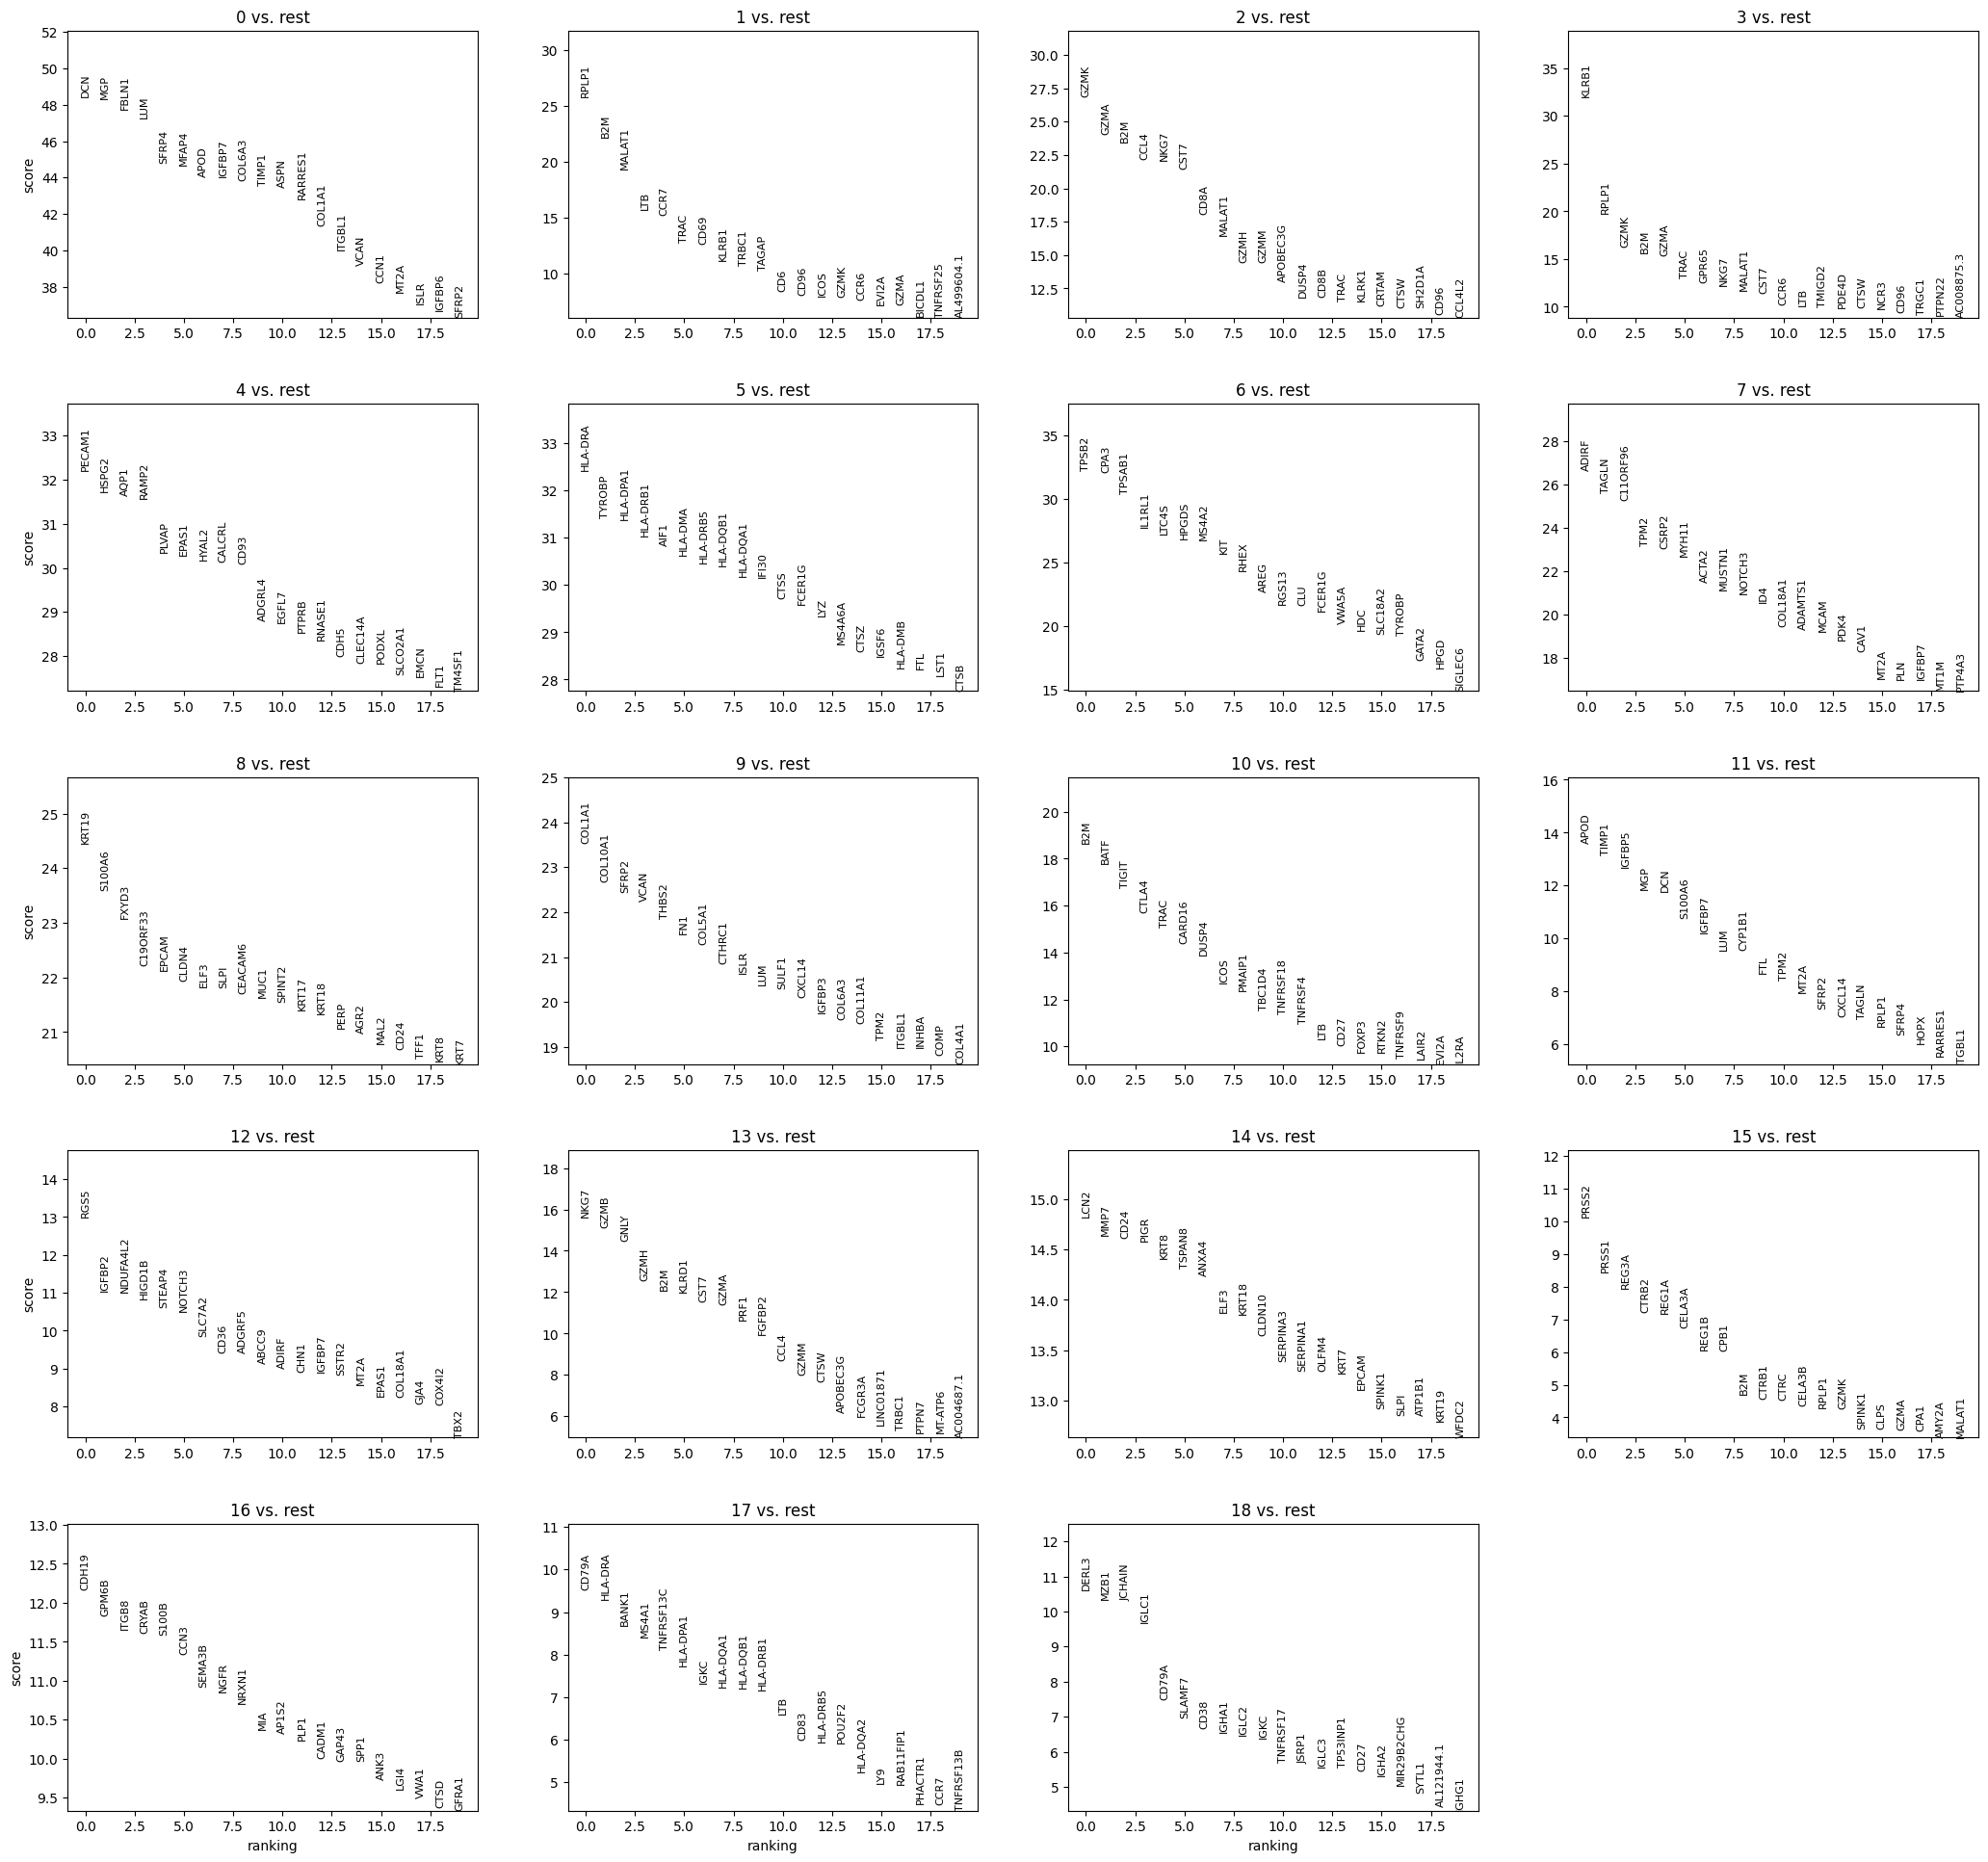

In [62]:
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)

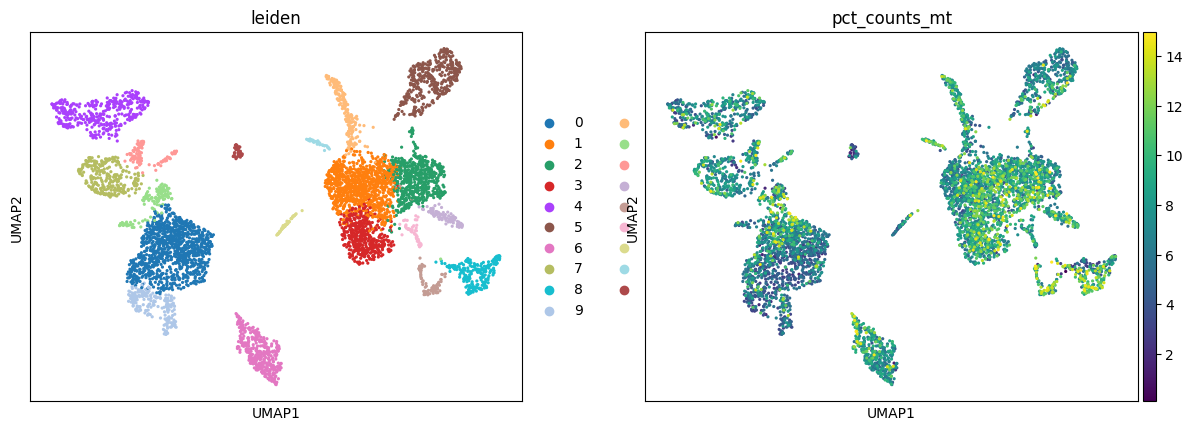

In [63]:
sc.pl.umap(adata, color=['leiden', 'pct_counts_mt'])

In [64]:
print(adata.obs.columns)

Index(['gsm', 'sample', 'condition', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes',
       'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes',
       'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt',
       'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo',
       'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes',
       'doublet_score', 'predicted_doublet', 'leiden_0.3', 'leiden_0.5',
       'leiden_0.8', 'leiden_1.0', 'leiden'],
      dtype='object')


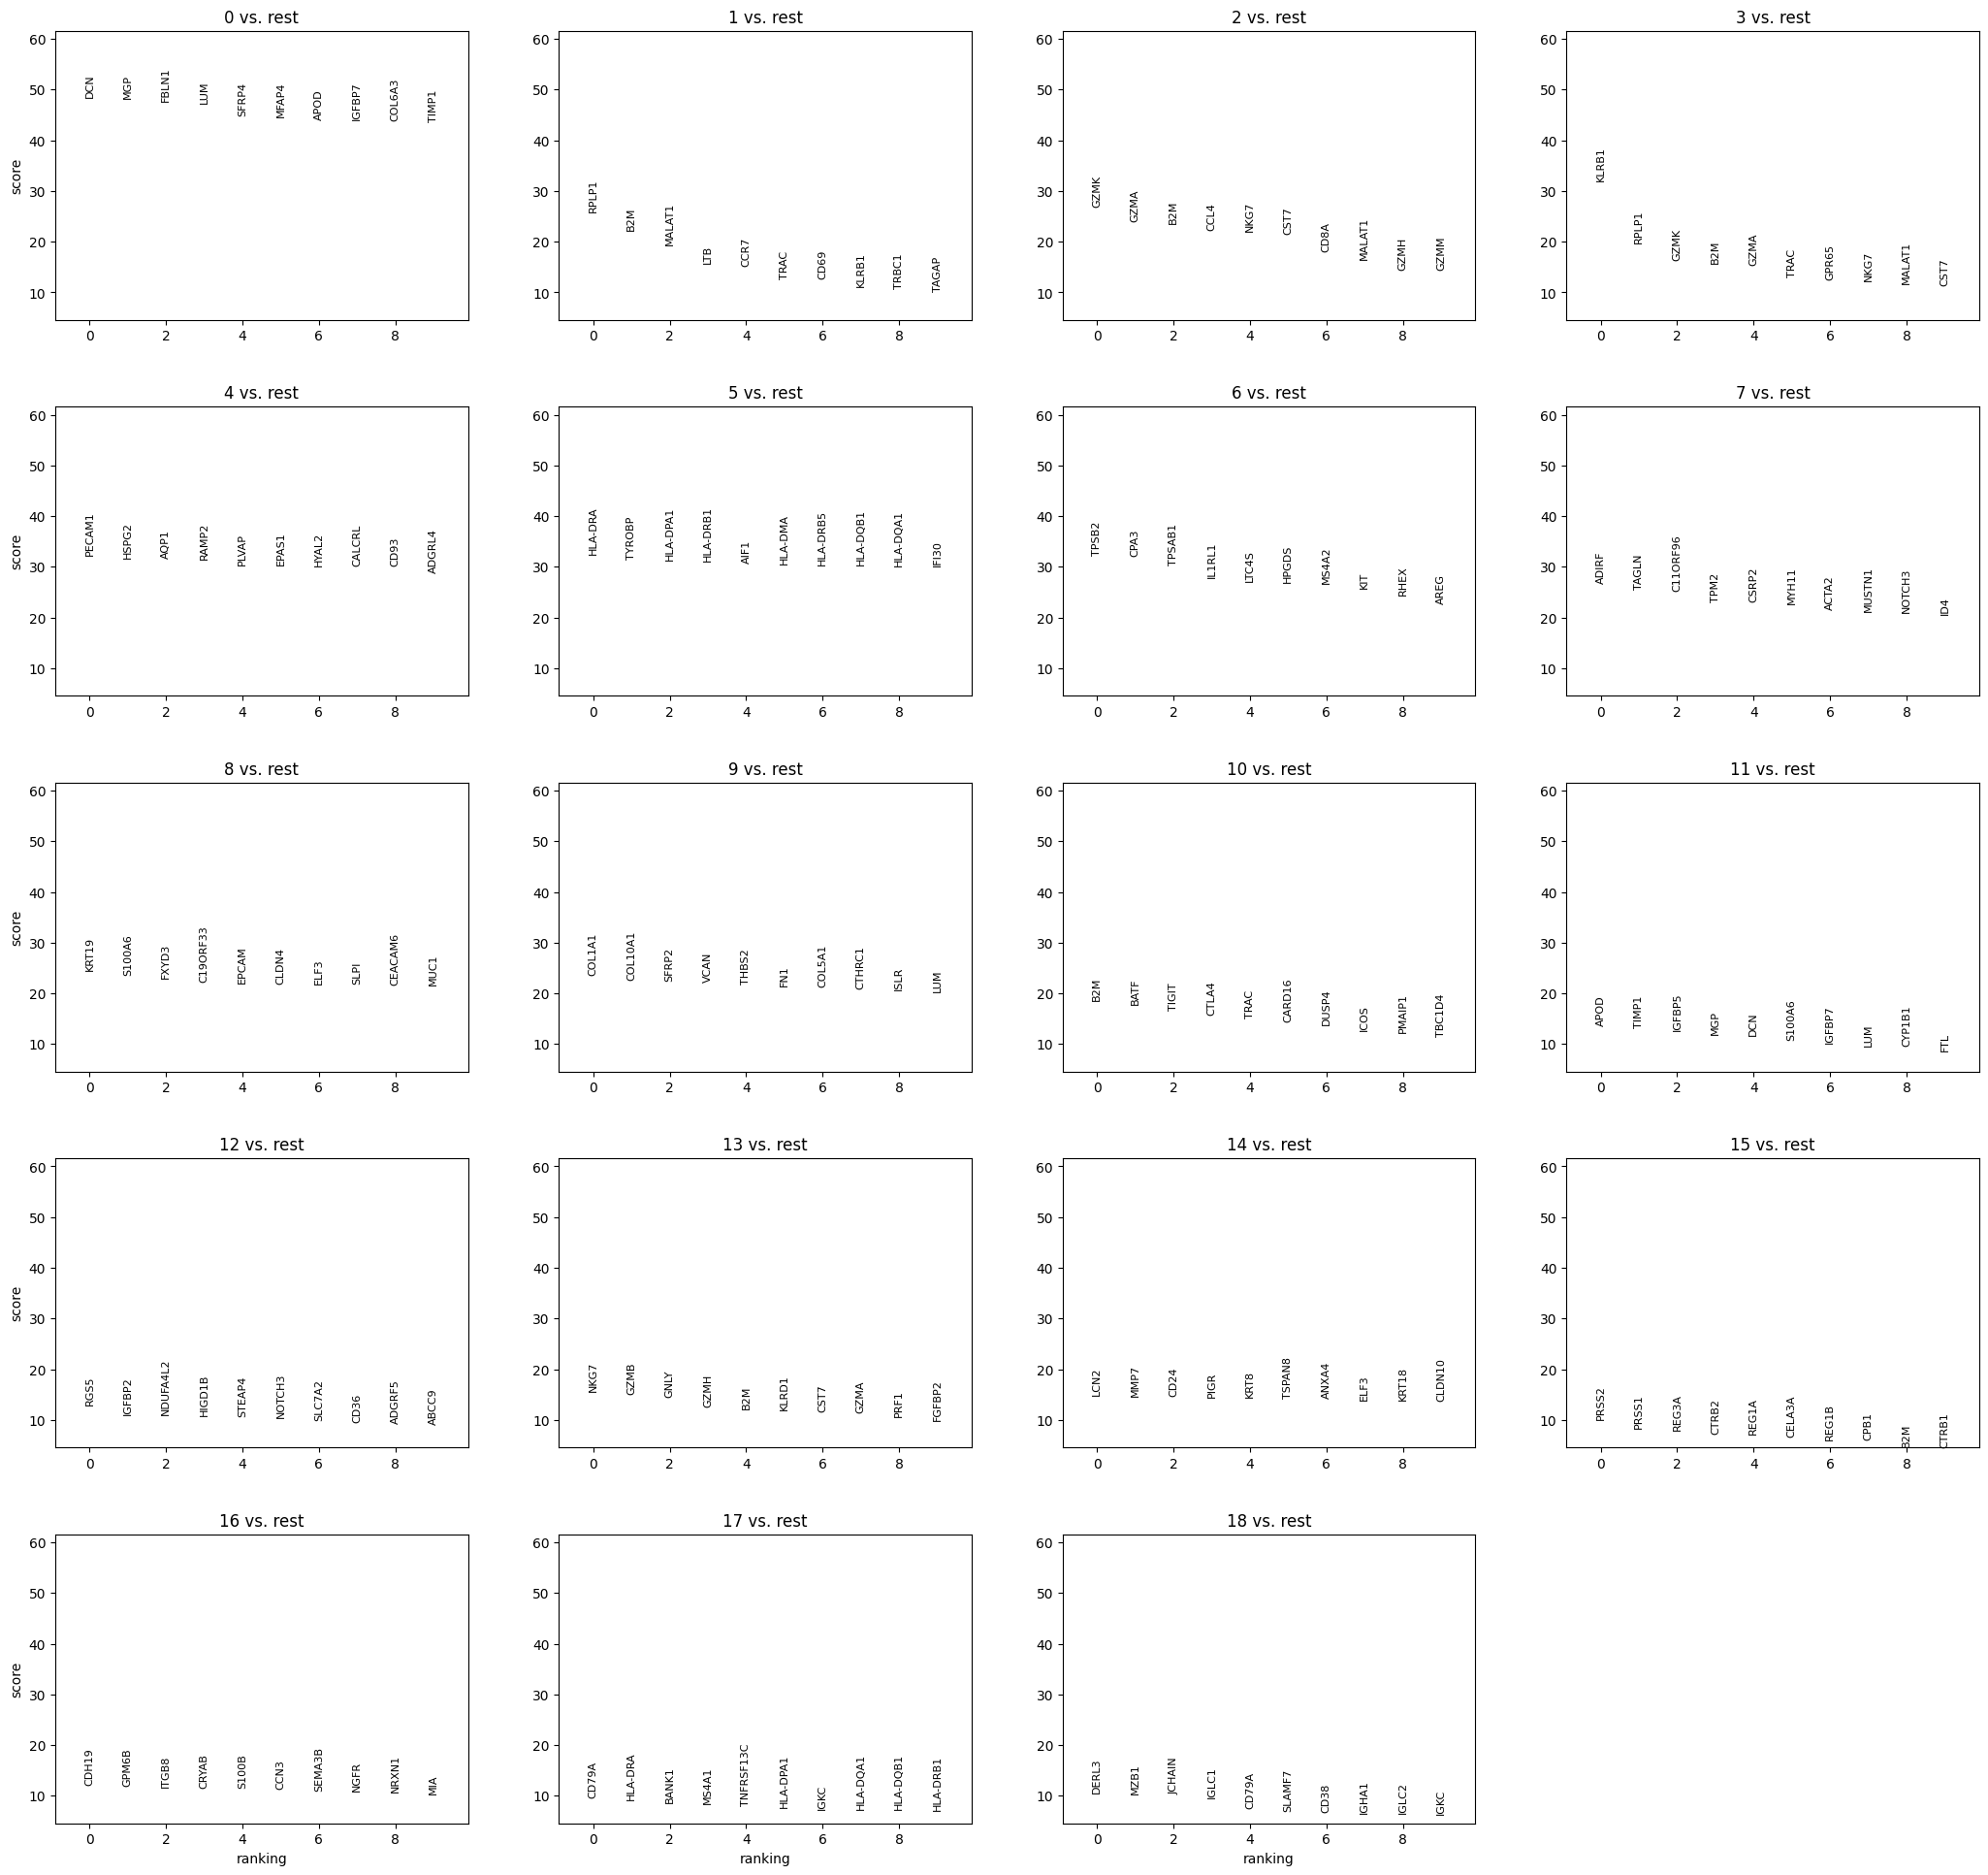

In [65]:
sc.pl.rank_genes_groups(adata, n_genes=10)

In [66]:
markers = pd.DataFrame(adata.uns['rank_genes_groups']['names'])
print(markers.head())

       0       1     2      3       4         5       6         7         8  \
0    DCN   RPLP1  GZMK  KLRB1  PECAM1   HLA-DRA   TPSB2     ADIRF     KRT19   
1    MGP     B2M  GZMA  RPLP1   HSPG2    TYROBP    CPA3     TAGLN    S100A6   
2  FBLN1  MALAT1   B2M   GZMK    AQP1  HLA-DPA1  TPSAB1  C11ORF96     FXYD3   
3    LUM     LTB  CCL4    B2M   RAMP2  HLA-DRB1  IL1RL1      TPM2  C19ORF33   
4  SFRP4    CCR7  NKG7   GZMA   PLVAP      AIF1   LTC4S     CSRP2     EPCAM   

         9     10      11        12    13    14     15     16         17  \
0   COL1A1    B2M    APOD      RGS5  NKG7  LCN2  PRSS2  CDH19      CD79A   
1  COL10A1   BATF   TIMP1    IGFBP2  GZMB  MMP7  PRSS1  GPM6B    HLA-DRA   
2    SFRP2  TIGIT  IGFBP5  NDUFA4L2  GNLY  CD24  REG3A  ITGB8      BANK1   
3     VCAN  CTLA4     MGP    HIGD1B  GZMH  PIGR  CTRB2  CRYAB      MS4A1   
4    THBS2   TRAC     DCN    STEAP4   B2M  KRT8  REG1A  S100B  TNFRSF13C   

       18  
0   DERL3  
1    MZB1  
2  JCHAIN  
3   IGLC1  
4   CD79

Guessing from ranked gene markers per cluster...

In [67]:
cluster_to_celltype = {
    '0': 'Fibroblasts',
    '1': 'T cells',
    '2': 'CD8+ T cells',
    '3': 'NK / activated T',
    '4': 'Endothelial',
    '5': 'Macrophages', # Myeloid cells
    '6': 'Mast cells',
    '7': 'Smooth muscle',
    '8': 'Tumor cells',
    '9': 'Fibroblasts (CAF)',
    '10': 'Exhausted T cells',
    '11': 'Tumor cells',
    '12': 'Hypoxic tumor',
    '13': 'CD8+ T cells',
    '14': 'Tumor cells',
    '15': 'Acinar cells',
    '16': 'Neural-like',
    '17': 'B cells',
    '18': 'Plasma cells'
}

adata.obs['cell_type'] = adata.obs['leiden'].map(cluster_to_celltype)

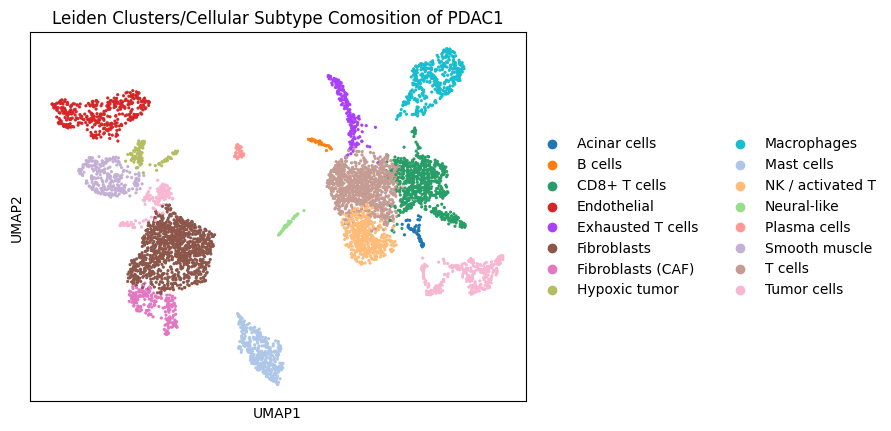

In [73]:
sc.pl.umap(
    adata,
    color=['cell_type'],
    title=[
        "Leiden Clusters/Cellular Subtype Comosition of PDAC1"
    ]
)